In [2]:
import json
from pathlib import Path
from collections import Counter

TACO_ROOT = Path("../data/raw/")
RESULTS_DIR = Path("../results")

ANNOTATIONS_PATH = TACO_ROOT / "annotations.json"

with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as f:
    annotations = json.load(f)

annotations.keys()

dict_keys(['info', 'images', 'annotations', 'scene_annotations', 'licenses', 'categories', 'scene_categories'])

In [3]:
num_images = len(annotations["images"])
num_annotations = len(annotations["annotations"])
num_categories = len(annotations["categories"])

print("Images:", num_images)
print("Annotations:", num_annotations)
print("Categories:", num_categories)

Images: 1500
Annotations: 4784
Categories: 60


In [4]:
import pandas as pd

categories = annotations["categories"]
categories_df = pd.DataFrame(categories)
categories_df.head()

,supercategory,id,name
0,Aluminium foil,0,Aluminium foil
1,Battery,1,Battery
2,Blister pack,2,Aluminium blister pack
3,Blister pack,3,Carded blister pack
4,Bottle,4,Other plastic bottle


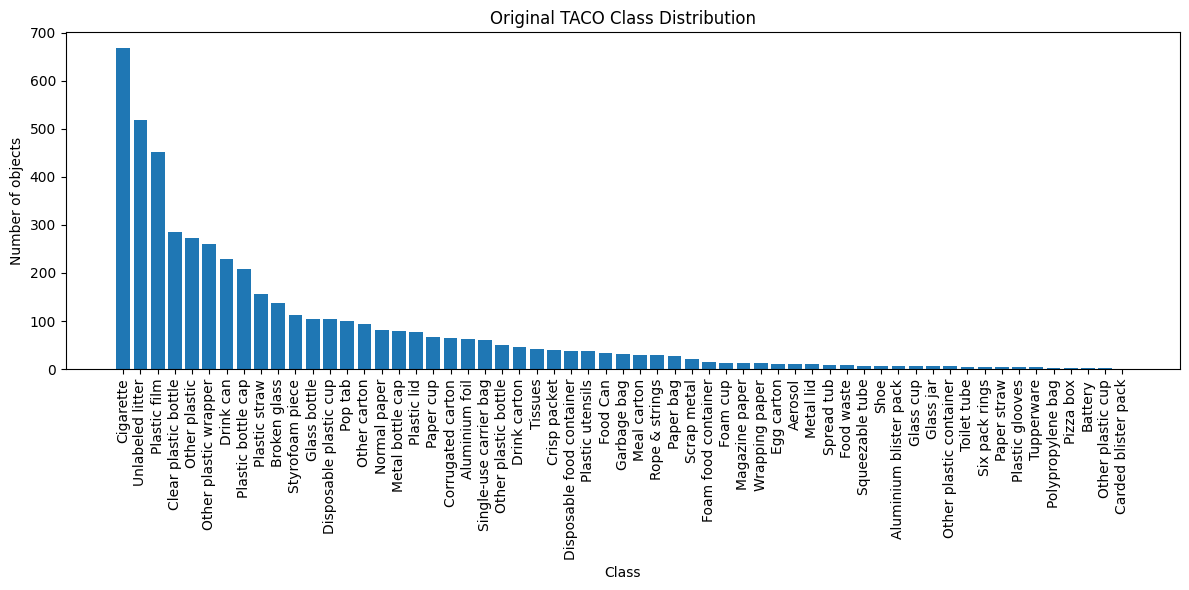

In [5]:
import matplotlib.pyplot as plt

category_id_to_name = {
    cat["id"]: cat["name"]
    for cat in annotations["categories"]
}

original_class_counts = Counter(
    category_id_to_name[ann["category_id"]]
    for ann in annotations["annotations"]
)

original_df = pd.DataFrame(
    original_class_counts.items(),
    columns=["class_name", "count"]
).sort_values("count", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(original_df["class_name"], original_df["count"])
plt.xticks(rotation=90)
plt.title("Original TACO Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.tight_layout()
plt.savefig("../results/original_class_distribution.png", dpi=200)
plt.show()

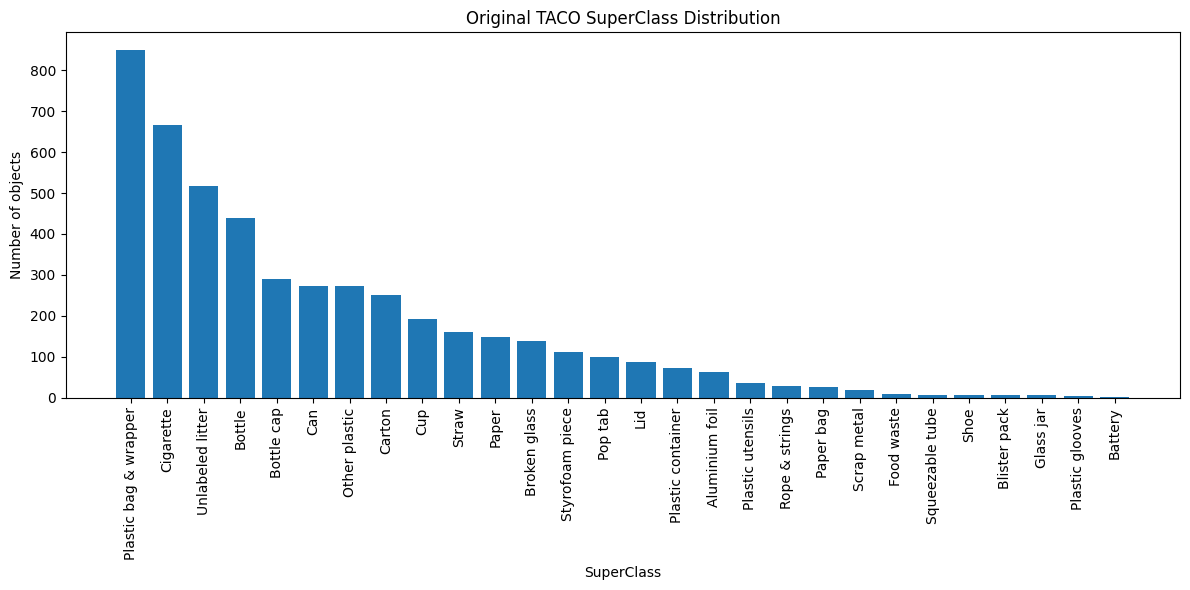

In [6]:
category_id_to_name = {
    cat["id"]: cat["supercategory"]
    for cat in annotations["categories"]
}

original_class_counts = Counter(
    category_id_to_name[ann["category_id"]]
    for ann in annotations["annotations"]
)

original_df = pd.DataFrame(
    original_class_counts.items(),
    columns=["class_name", "count"]
).sort_values("count", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(original_df["class_name"], original_df["count"])
plt.xticks(rotation=90)
plt.title("Original TACO SuperClass Distribution")
plt.xlabel("SuperClass")
plt.ylabel("Number of objects")
plt.tight_layout()
plt.savefig("../results/original_super_class_distribution.png", dpi=200)
plt.show()

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.class_mapping import (
    COARSE_CLASSES,
    COARSE_CLASS_TO_ID,
    map_taco_category_to_coarse,
    map_taco_category_to_coarse_id,
)

mapping_rows = []

for category in annotations["categories"]:
    name = category["name"]
    supercategory = category.get("supercategory", "")

    coarse_class = map_taco_category_to_coarse(name, supercategory)
    coarse_class_id = map_taco_category_to_coarse_id(name, supercategory)

    mapping_rows.append(
        {
            "original_id": category["id"],
            "original_name": name,
            "original_supercategory": supercategory,
            "coarse_class": coarse_class,
            "coarse_class_id": coarse_class_id,
        }
    )

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(RESULTS_DIR / "class_mapping_table.csv", index=False)

mapping_df


,original_id,original_name,original_supercategory,coarse_class,coarse_class_id
0,0,Aluminium foil,Aluminium foil,metal,3
1,1,Battery,Battery,other,5
2,2,Aluminium blister pack,Blister pack,metal,3
3,3,Carded blister pack,Blister pack,other,5
4,4,Other plastic bottle,Bottle,rigid_plastic,0
5,5,Clear plastic bottle,Bottle,rigid_plastic,0
6,6,Glass bottle,Bottle,glass,4
7,7,Plastic bottle cap,Bottle cap,rigid_plastic,0
8,8,Metal bottle cap,Bottle cap,metal,3
9,9,Broken glass,Broken glass,glass,4


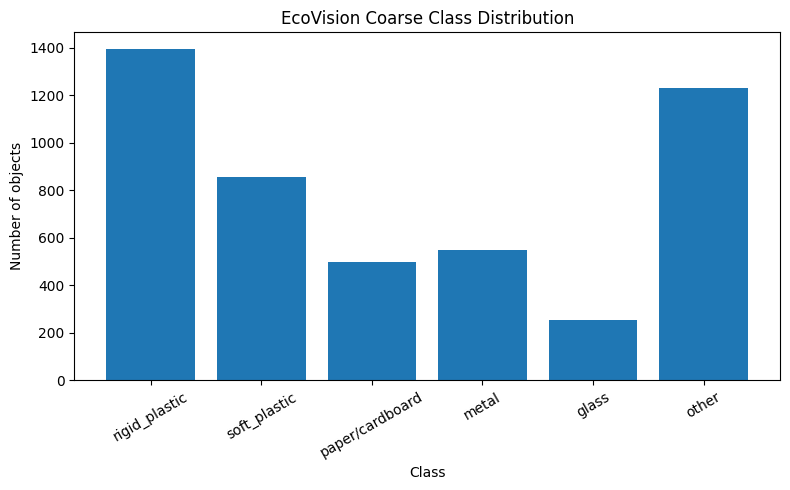

,class_id,class_name,count
0,0,rigid_plastic,1395
1,1,soft_plastic,857
2,2,paper/cardboard,497
3,3,metal,550
4,4,glass,254
5,5,other,1231


In [10]:
category_id_to_info = {
    category["id"]: {
        "name": category["name"],
        "supercategory": category.get("supercategory", ""),
    }
    for category in annotations["categories"]
}

coarse_counts = Counter()

for annotation in annotations["annotations"]:
    category_info = category_id_to_info[annotation["category_id"]]

    coarse_class = map_taco_category_to_coarse(
        name=category_info["name"],
        supercategory=category_info["supercategory"],
    )

    coarse_counts[coarse_class] += 1

coarse_df = pd.DataFrame(
    [
        {
            "class_id": COARSE_CLASS_TO_ID[class_name],
            "class_name": class_name,
            "count": coarse_counts.get(class_name, 0),
        }
        for class_name in COARSE_CLASSES
    ]
)

coarse_df.to_csv(RESULTS_DIR / "coarse_class_counts.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(coarse_df["class_name"], coarse_df["count"])
plt.title("EcoVision Coarse Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "coarse_class_distribution.png", dpi=200)
plt.show()

coarse_df